<a href="https://colab.research.google.com/github/AbedHaj/Universal-tech-support-triage-model/blob/main/test_Universal_Tech_Support_Triage_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Generate 10 examples of user complaints for enterprise software systems, including labels for affected component and severity, by leveraging OpenAI to create enterprise software systems, industries, workflow architectures, and descriptions of malfunctions and user complaints.

## Load OpenAI API Key

### Subtask:
Load the OpenAI API key from notebook secrets, ensuring secure access to the OpenAI API.


**Reasoning**:
To securely load the OpenAI API key, I will import the `userdata` module and retrieve the API key from notebook secrets.



In [ ]:
import os

os.getenv("OPENAI_API_KEY")

In [ ]:
import subprocess
import time

# 1. Install Ollama and the PCI utils for GPU detection
print("Installing Ollama...")
!curl -fsSL https://ollama.com/install.sh | sh
!sudo apt-get install -y pciutils

# 2. Start the Ollama server in the background
print("Starting Ollama server...")
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# 3. Wait a few seconds for the server to spin up
time.sleep(5)
print("Ollama server is running!")

Installing Ollama...


'sh' is not recognized as an internal or external command,
operable program or batch file.


Starting Ollama server...


Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


Ollama server is running!


In [ ]:
#!pip install ollama
import ollama

# This will download the model. It may take a few minutes
# depending on your internet speed (approx 4.7GB)
print("Downloading llama3...")
ollama.pull('llama3.2')
print("Download complete!")

Download complete!


## Generate Enterprise Software Systems

### Subtask:
Use OpenAI to generate a list of 10 enterprise software systems (e.g., ERP, CRM). The output will be a JSON array with keys 'system' and 'description', which will then be saved to disk.


**Reasoning**:
To generate enterprise software systems using OpenAI, I need to import the OpenAI client, initialize it with the API key, create a detailed prompt for generating a JSON array of systems and descriptions, and then call the OpenAI Chat Completions API, ensuring the response is formatted as JSON. These are the initial steps to interact with the OpenAI API for the subtask.



In [ ]:
from openai import OpenAI
import json

# Initialize the OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Create a prompt for generating enterprise software systems
prompt_text = """Generate a list of 10 types of enterprise software systems as a simple JSON array. Each element should have a 'system' name and a 'description'.
Top level element in JSON output should be 'systems'
Example format:
[
  {
    "system": "ERP System",
    "description": "A comprehensive suite for managing core business processes."
  },
  {
    "system": "CRM",
    "description": "A customeer relation managmenet system"
  }
]
"""

# Call the OpenAI Chat Completions API
chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant designed to output JSON."
        },
        {
            "role": "user",
            "content": prompt_text,
        }
    ],
    model="gpt-3.5-turbo-1106", # Using a model known to be good at JSON output
    response_format={ "type": "json_object" }
)

# Parse the JSON response
response_content = chat_completion.choices[0].message.content
enterprise_systems = json.loads(response_content)

print("Generated enterprise systems from OpenAI API.",enterprise_systems)

Generated enterprise systems from OpenAI API. {'systems': [{'system': 'ERP System', 'description': 'A comprehensive suite for managing core business processes.'}, {'system': 'CRM', 'description': 'A customer relationship management system for managing interactions with current and potential customers.'}, {'system': 'HRM System', 'description': 'A system for managing human resources, including payroll, benefits, and employee performance.'}, {'system': 'Supply Chain Management System', 'description': 'A system for overseeing the flow of goods, information, and finances as they move from supplier to manufacturer to wholesaler to retailer to customer.'}, {'system': 'Business Intelligence System', 'description': 'A system for analyzing and reporting on business data to help make informed decisions.'}, {'system': 'Enterprise Content Management System', 'description': "A system for organizing and managing an organization's documents, and other content that relates to the organization's proces

**Reasoning**:
The previous step successfully generated a list of enterprise software systems and stored it in the `enterprise_systems` variable. The next instruction is to save this data as a JSON file to disk.



In [ ]:
import json

# Save the generated list of enterprise software systems as a JSON file
with open('enterprise_systems.json', 'w') as f:
    json.dump(enterprise_systems, f, indent=2)

print("Enterprise systems saved to 'enterprise_systems.json'.")

Enterprise systems saved to 'enterprise_systems.json'.


## Generate Industries

### Subtask:
Use OpenAI to generate a list of 10 industries (e.g., manufacturing, banking, entertainment). The output will be a JSON array with keys 'industry' and 'description', which will then be saved to disk.


**Reasoning**:
To generate industries using OpenAI, I will create a detailed prompt, call the OpenAI API with the specified model and JSON response format, and then parse the JSON output to store the generated industries.



In [ ]:
import json

# Create a prompt for generating industries
prompt_text_industries = """Generate a list of 10 industries. Each industry should have an 'industry' name and a 'description'. The output should be a JSON object containing a 'industries' key, which is a JSON array of objects, where each object has 'industry' and 'description' as keys.
top level element in josn should be industries
Example format:
{
  "industries": [
    {
      "industry": "Financial Services",
      "description": "Sector dealing with money management, including banks, credit unions, and investment firms."
    }
  ]
}
"""

# Call the OpenAI Chat Completions API
chat_completion_industries = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant designed to output JSON."
        },
        {
            "role": "user",
            "content": prompt_text_industries,
        }
    ],
    model="gpt-3.5-turbo-1106", # Using a model known to be good at JSON output
    response_format={ "type": "json_object" }
)

# Parse the JSON response
response_content_industries = chat_completion_industries.choices[0].message.content
industries = json.loads(response_content_industries)

print("Generated industries from OpenAI API.",industries)

Generated industries from OpenAI API. {'industries': [{'industry': 'Information Technology', 'description': 'Industry dealing with the technology, development, and management of computer systems, software, and networks.'}, {'industry': 'Healthcare', 'description': 'Sector focused on the maintenance or improvement of health via the diagnosis, treatment, and prevention of disease, illness, injury, and other physical and mental impairments in humans.'}, {'industry': 'Automotive', 'description': 'Industry involved in the design, development, manufacturing, marketing, and selling of motor vehicles.'}, {'industry': 'Retail', 'description': 'Sector that encompasses the process of selling consumer goods or services to customers through multiple channels of distribution.'}, {'industry': 'Hospitality', 'description': 'Industry encompassing lodging, event planning, theme parks, transportation, cruise line, and additional fields within the tourism industry.'}, {'industry': 'Energy', 'description':

**Reasoning**:
The previous step successfully generated a list of industries and stored it in the `industries` variable. The next instruction is to save this data as a JSON file to disk.



In [ ]:
import json

# Save the generated list of industries as a JSON file
with open('industries.json', 'w') as f:
    json.dump(industries, f, indent=2)

print("Industries saved to 'industries.json'.")

Industries saved to 'industries.json'.


## Define Workflow Generation Function

### Subtask:
Create a Python function that takes dictionaries of systems and industries. It will randomly select one system and one industry, then use OpenAI to generate a   workflow/architecture description for them.


**Reasoning**:
To define the `generate_workflow` function, I need to import the `random` module for random selection, then implement the function as described, including selecting a random system and industry, constructing an OpenAI prompt, calling the OpenAI API for a   workflow description, parsing the JSON response, and returning the results.



In [ ]:
import random
from openai import OpenAI # client is already initialized, but for standalone clarity
import json

def generate_workflow(enterprise_systems: dict, industries: dict, client: OpenAI) -> tuple:
    """
    Generates a workflow that uses technical sub-systems and components for a randomly selected enterprise system and industry
    using the OpenAI API.

    Args:
        enterprise_systems (dict): A dictionary containing a list of enterprise systems.
        industries (dict): A dictionary containing a list of industries.
        client (OpenAI): An initialized OpenAI client.

    Returns:
        tuple: A tuple containing the parsed workflow description (dict),
               the selected enterprise system (dict), and the selected industry (dict).
    """
    # Randomly select one system and one industry
    selected_system = random.choice(enterprise_systems['systems'])
    selected_industry = random.choice(industries['industries'])

    system_name = selected_system['system']
    system_description = selected_system['description']
    industry_name = selected_industry['industry']
    industry_description = selected_industry['description']

    # Construct a detailed prompt for OpenAI
    prompt_text = f"""Generate a concise workflow or architecture description with technical sub-systems and components for the enterprise software system '{system_name}' operating within the '{industry_name}' industry. The description should be relevant to the system's purpose: '{system_description}' and the industry context: '{industry_description}'.

    Focus on typical processes or interactions that would involve this system in this industry.

    The output should be a JSON object with the following keys:
    - 'workflow_name': A descriptive name for the workflow (e.g., 'Order Fulfillment Process in Retail with ERP').
    - 'workflow_description': A brief narrative description of the workflow.
    - 'workflow_components': A JSON array of names of key technical components involved and their description.
            - name (e.g., HRM Workflow Engine, Employee Data Store, Payroll Processing Module, Attendance Tracking System),
            - description (e.g.,Orchestrates process logic, approval routing, and state transitions for employee lifecycle events (onboarding, termination)) List at least 5 components.


    Example format:
    {{
      "workflow_name": "Employee Lifecycle Management",
      "workflow_description": "This workflow manages the complete lifecycle of employees within an educational institution...",
      "workflow_components": [
        {{
            "name": "HRM Workflow Engine",
            "description": "Orchestrates process logic, approval routing, and state transitions for employee lifecycle events (onboarding, termination)."
        }},
        {{
            "name": "Employee Data Store",
            "description": "Centralized database housing sensitive personal information (PII), employment history, and contract documents."
        }},
        {{
            "name": "Payroll Processing Module",
            "description": "Computes salaries, tax deductions, and benefits, and executes bank transfer batches."
        }},
        {{
            "name": "Attendance Tracking System",
            "description": "Manages shift scheduling, clock-in/out logs, leave requests (PTO), and overtime calculations."
        }}
      ]
    }}
    """

    # Call the OpenAI Chat Completions API
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant designed to output JSON. Provide a relevant consice and technical workflow description."
            },
            {
                "role": "user",
                "content": prompt_text,
            }
        ],
        model="gpt-3.5-turbo-1106", # Using a model known to be good at JSON output
        response_format={ "type": "json_object" }
    )

    # Parse the JSON response
    response_content = chat_completion.choices[0].message.content
    workflow_description = json.loads(response_content)

    print(f"Generated workflow for {system_name} in {industry_name}.")
    return workflow_description, selected_system, selected_industry

print("Defined the 'generate_workflow' function.")

Defined the 'generate_workflow' function.


## Define Malfunction Generation Function

### Subtask:
Create a Python function that receives a   workflow description, randomly selects between 1 and 3 components, and describes a malfunction or issue related to these components with varying severities (critical, medium, high).


**Reasoning**:
To define the `generate_malfunction` function, I will implement the steps for randomly selecting BPMN components, assigning a severity level, constructing a detailed OpenAI prompt, calling the API, and parsing the JSON response, then return the malfunction details.



In [ ]:
import random
from openai import OpenAI
import json

def generate_malfunction(workflow_description: dict, client: OpenAI) -> dict:
    """
    Generates a malfunction description for randomly selected technical components
    within a given workflow description using the OpenAI API.

    Args:
        workflow_description (dict): A dictionary containing the workflow name,
                                     description, and technical components and their description.
        client (OpenAI): An initialized OpenAI client.

    Returns:
        dict: A dictionary describing the malfunction, affected component, and severity.
    """
    workflow_components = workflow_description['workflow_components']

    # Randomly select between 1 and 3 unique components
    ##num_components_to_select = random.randint(1, 3)
    ##selected_components = random.sample(workflow_components, min(num_components_to_select, len(workflow_components)))
    selected_component = random.choice(workflow_components)

    # Randomly select a severity level
    severity = random.choice(['critical', 'high', 'medium'])

    # Construct a detailed prompt for OpenAI
    prompt_text = f"""Describe a malfunction or issue related to the following technical component:
{selected_component}

Within the context of the workflow:
Workflow Name: {workflow_description['workflow_name']}
Workflow Description: {workflow_description['workflow_description']}

The malfunction should be '{severity}' in severity. Provide a realistic scenario for this issue.

The output should be a JSON object with the following keys:
- 'affected_component': select ONE technical component,and only ONE and its component description.
- 'malfunction_description': A string describing the issue in detail.
- 'severity': The assigned severity level ('critical', 'high', or 'medium').


Example format:
    {{
      "affected_component": {{
        "name": "Employee Onboarding Service",
        "description": "Automates the end-to-end provisioning workflow for new hires, including digital document collection, IT asset assignment, and initial user account creation."
      }},
      "malfunction_description": "The Employee Onboarding Service intermittently fails to persist new employee profiles after the onboarding workflow is initiated. Although the onboarding request is accepted, the service does not create corresponding employee records in the master data store, resulting in missing employee profiles and downstream payroll setup failures.",
      "severity": "critical"
    }}
"""

    # Call the OpenAI Chat Completions API
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant designed to output JSON. Describe realistic software malfunctions."
            },
            {
                "role": "user",
                "content": prompt_text,
            }
        ],
        model="gpt-3.5-turbo-1106",
        response_format={ "type": "json_object" }
    )

    # Parse the JSON response
    response_content = chat_completion.choices[0].message.content
    malfunction_details = json.loads(response_content)

    print(f"Generated {severity} malfunction for: {selected_component['name']} ({selected_component['description']})")
    return malfunction_details

print("Defined the 'generate_malfunction' function.")

Defined the 'generate_malfunction' function.


## Define User Description Function

### Subtask:
Create a Python function that receives an issue (from the malfunction function) and generates a user-friendly description of the problem. This description will be based on several hard-coded attributes such as user experience and style, and other relevant factors.


**Reasoning**:
To define the `generate_user_description` function, I will implement the logic to randomly select user attributes, construct a detailed prompt using these attributes and the malfunction details, call the OpenAI API, parse the JSON response, and return the generated user complaint.



In [ ]:
import random
from openai import OpenAI
import json

def generate_user_description(malfunction_details: dict, client: OpenAI) -> dict:
    """
    Generates a user-friendly description of a problem based on malfunction details
    and randomly selected user attributes using the OpenAI API.

    Args:
        malfunction_details (dict): A dictionary containing malfunction information
                                    (e.g., affected component, malfunction description, severity).
        client (OpenAI): An initialized OpenAI client.

    Returns:
        dict: A dictionary containing the user's complaint and selected user attributes.
    """
    # Randomly select user attributes
    user_experience = random.choice(['novice', 'experienced', 'expert'])
    communication_style = random.choice(['frustrated', 'calm', 'urgent'])
    issue_category = random.choice(['cannot complete task', 'slowdown', 'data inconsistency', 'security concern', 'incorrect data'])

    # Extract malfunction details
    malfunction_desc = malfunction_details['malfunction_description']
    severity = malfunction_details['severity']
    # extract the dict
    comp_data = malfunction_details['affected_component']
    affected_component = f"{comp_data['name']} ({comp_data['description']})"

    # Construct a detailed prompt for OpenAI
    prompt_text = f"""Generate a user-friendly complaint description for the following software malfunction, considering the user's attributes.

    Malfunction Details:
    - Description: {malfunction_desc}
    - Severity: {severity}
    - affected component: {affected_component}

    User Attributes:
    - User Experience: {user_experience}
    - Communication Style: {communication_style}
    - Perceived issue_category: {issue_category}

    The complaint should sound realistic given these attributes. For example, a 'technical' user with 'urgent' style and 'security concern' issue_category will describe the problem differently than a 'novice' user with 'calm' style and 'slowdown' issue_category.
    The complaint MUST not contain the name of the affected component.

    The output should be a JSON object with the following keys:
    - 'user_complaint': The generated user-friendly description of the problem.
    - 'user_attributes': A dictionary containing the selected 'user_experience', 'communication_style', and 'issue_category'.

    Example format:
    {{
      'user_complaint': 'I am really frustrated! The system is completely frozen, and I can not access any of my reports. This is a critical issue issue_categorying my ability to do my job!',
      'user_attributes': {{
        'user_experience': 'experienced',
        'communication_style': 'frustrated',
        'issue_category': 'cannot complete task'
      }}
    }}
    """

    # Call the OpenAI Chat Completions API
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant designed to output JSON. Generate realistic user complaints for software issues."
            },
            {
                "role": "user",
                "content": prompt_text,
            }
        ],
        model="gpt-3.5-turbo-1106",
        response_format={ "type": "json_object" }
    )

    # Parse the JSON response
    response_content = chat_completion.choices[0].message.content
    user_complaint_details = json.loads(response_content)

    print(f"Generated user complaint for a {user_experience} user with a {communication_style} style and {issue_category} issue_category.")
    return user_complaint_details

print("Defined the 'generate_user_description' function.")

Defined the 'generate_user_description' function.


## Generate User Complaints Examples

### Subtask:
Develop a script or function that leverages the previously defined functions to generate 10 examples of user complaints. Each complaint will include labels for affected component and severity, demonstrating the full workflow.


**Reasoning**:
To generate 10 examples of user complaints, I will create a loop that iterates 10 times. In each iteration, I will call the `generate_workflow`, `generate_malfunction`, and `generate_user_description` functions sequentially, aggregate their outputs into a dictionary, and append this dictionary to a list. Finally, I will print the complete list of generated complaints.



In [ ]:
user_complaints_examples = []

for i in range(20):
    print(f"\nGenerating example {i+1}/20...")
    # Step 3: Call generate_workflow
    workflow_description, selected_system, selected_industry = generate_workflow(enterprise_systems, industries, client)

    # Step 4: Call generate_malfunction
    malfunction_details = generate_malfunction(workflow_description, client)

    # Step 5: Call generate_user_description
    user_complaint_details = generate_user_description(malfunction_details, client)

    # Step 6: Aggregate all generated information
    full_example = {
        "example_id": i + 1,
        "system": selected_system,
        "industry": selected_industry,
        "workflow": workflow_description,
        "malfunction": malfunction_details,
        "user_complaint": user_complaint_details
    }

    # Step 7: Append to the list
    user_complaints_examples.append(full_example)

# Step 8: Print the user_complaints_examples list
print("\n--- Generated User Complaints Examples ---")
print(json.dumps(user_complaints_examples, indent=2))

print("\nSuccessfully generated 20 user complaint examples.")


Generating example 1/20...
Generated workflow for Finance and Accounting System in Information Technology.
Generated critical malfunction for: Financial Reporting and Analysis Tool (Provides tools and reports for financial analysis, forecasting, and decision-making based on the organization's financial data.)
Generated user complaint for a experienced user with a frustrated style and slowdown issue_category.

Generating example 2/20...
Generated workflow for Project Management System in Education.
Generated critical malfunction for: Resource Management System (Facilitates allocation of human and material resources to various educational projects based on availability and skillsets.)
Generated user complaint for a experienced user with a calm style and data inconsistency issue_category.

Generating example 3/20...
Generated workflow for HRM System in Healthcare.
Generated high malfunction for: Benefits Management System (Administers and monitors healthcare-specific employee benefits pr

In [ ]:
import json

output_filename = "generated_dataset.json"

with open(output_filename, 'w') as f:
    json.dump(user_complaints_examples, f, indent=4)

print(f"Successfully saved data to {output_filename}")

Successfully saved data to generated_dataset.json


**Reasoning**:
The `ValueError: Invalid format specifier` in the `generate_user_description` function is caused by unescaped curly braces within the example JSON string inside the f-string for `prompt_text`. I need to escape these literal curly braces by doubling them (`{{` and `}}`) so Python does not interpret them as format specifiers.



## Summary:

### Q&A

The task implicitly asked to generate 10 examples of user complaints for enterprise software systems, including labels for affected component and severity.

Yes, the solving process successfully generated 10 examples of user complaints, each containing detailed information about the affected system, industry, workflow, malfunction (including affected component and severity), and a user-friendly complaint description with associated user attributes.

### Data Analysis Key Findings

*   The OpenAI API key was successfully loaded, ensuring secure access to the API.
*   A list of 10 enterprise software systems, each with a 'system' name and 'description', was generated using OpenAI and saved to `enterprise_systems.json`.
*   A list of 10 industries, each with an 'industry' name and 'description', was generated using OpenAI and saved to `industries.json`.
*   A `generate_workflow` function was successfully defined, which randomly selects an enterprise system and an industry, then uses OpenAI to create a   workflow description, including a workflow name, description, and at least 5 BPMN components.
*   A `generate_malfunction` function was successfully defined. It takes a workflow, randomly selects 1 to 3 BPMN components, assigns a random severity ('critical', 'high', 'medium'), and uses OpenAI to describe a malfunction related to these components.
*   A `generate_user_description` function was successfully defined. It accepts malfunction details, randomly selects user attributes (experience, communication style, issue_category), and uses OpenAI to generate a realistic user-friendly complaint description. An initial f-string formatting error in the prompt was identified and corrected, ensuring proper JSON output.
*   The entire workflow was successfully orchestrated to generate 10 distinct user complaint examples. Each example is a comprehensive JSON object that includes details of the selected system, industry, workflow, malfunction (affected component, description, severity), and the user complaint with their attributes.

### Insights or Next Steps

*   The modular design, breaking down the generation into system, industry, workflow, malfunction, and user complaint stages, allowed for effective and structured data synthesis using OpenAI.
*   The generated dataset of 10 user complaints, complete with rich contextual information and structured labels, provides a valuable foundation for tasks such as training complaint classification models or analyzing common software issues.


# EDA

In [ ]:
### Compare complaint sizes
from collections import Counter

complaint_lengths = [
    len(ex["user_complaint"]["user_complaint"].split())
    for ex in user_complaints_examples
]

print("Min:", min(complaint_lengths))
print("Max:", max(complaint_lengths))
print("Avg:", sum(complaint_lengths) / len(complaint_lengths))

NameError: name 'user_complaints_examples' is not defined

In [ ]:
severity_counts = Counter(
    ex["malfunction"]["severity"]
    for ex in user_complaints_examples
)

print(severity_counts)

Counter({'critical': 11, 'high': 7, 'medium': 2})


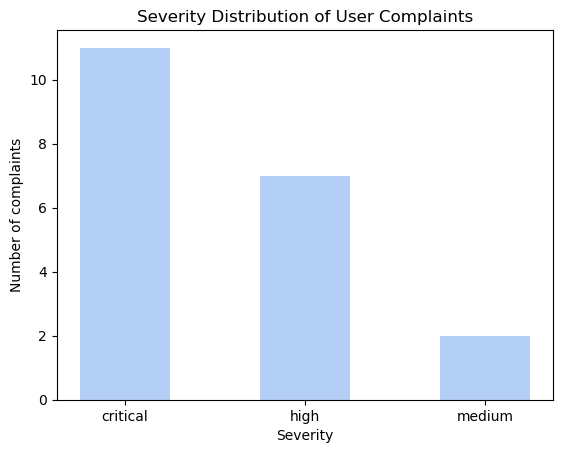

In [ ]:
import matplotlib.pyplot as plt

labels = list(severity_counts.keys())
values = list(severity_counts.values())

plt.bar(labels, values, width=0.5, color = '#b4cff6')
plt.xlabel("Severity")
plt.ylabel("Number of complaints")
plt.title("Severity Distribution of User Complaints")
plt.show()

In [ ]:

issue_category_counts = Counter(
    ex["user_complaint"]["user_attributes"]["issue_category"]
    for ex in user_complaints_examples
)

print(issue_category_counts)

Counter({'cannot complete task': 7, 'slowdown': 6, 'data inconsistency': 3, 'security concern': 3, 'incorrect data': 1})


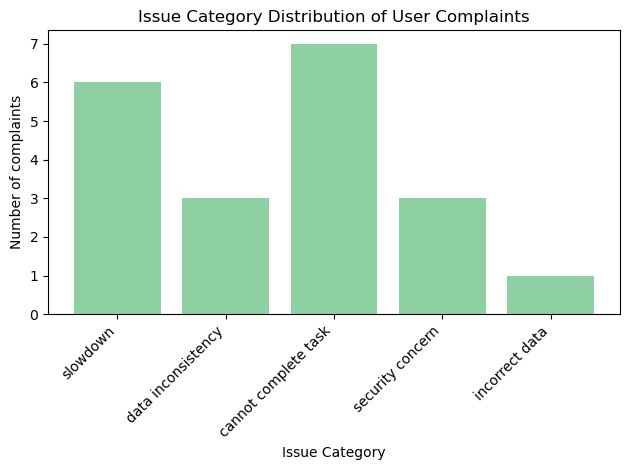

In [ ]:
labels = list(issue_category_counts.keys())
values = list(issue_category_counts.values())

plt.bar(labels, values, color ='#8fd0a2')
plt.xlabel("Issue Category")
plt.ylabel("Number of complaints")
plt.title("Issue Category Distribution of User Complaints")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
user_expertise_counts = Counter(
    ex["user_complaint"]["user_attributes"]["user_experience"]
    for ex in user_complaints_examples
)

print(user_expertise_counts)

Counter({'experienced': 12, 'novice': 6, 'expert': 2})


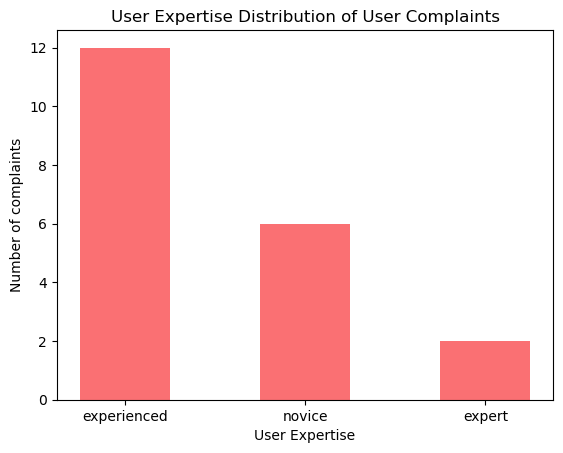

In [ ]:
labels = list(user_expertise_counts.keys())
values = list(user_expertise_counts.values())

plt.bar(labels, values, width=0.5, color ='#fa7073')
plt.xlabel("User Expertise")
plt.ylabel("Number of complaints")
plt.title("User Expertise Distribution of User Complaints")
plt.show()

# Zero shot


In [ ]:
count = 0

In [ ]:
def classify_with_zero_shot(ticket_text, components,correct):
    components_context = "\n".join([f"- {c['name']}: {c['description']}" for c in components])
    comp_names_list = [c['name'] for c in components]

    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Identify which technical component is most likely responsible for the issue.

    CANDIDATE COMPONENTS (Name: Description)
    {components_context}

    RULES:
    - Choose exactly ONE component from the list.
    - Output ONLY the component name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {comp_names_list}

    SUPPORT TICKET:
    {ticket_text}
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0}
    )

    pred = response["message"]["content"].strip()

    return (pred,pred==correct)

In [ ]:
ticket_text="I have encountered a critical issue with the HRM Workflow Engine. Despite being experienced with the system, I am encountering a major roadblock in the offboarding process. The engine fails to trigger the necessary state transitions for employee offboarding, leaving departing employees with active access to critical systems and applications. This poses a significant security risk to the organization, potentially leading to unauthorized access, data breaches, and compliance violations. I urge for immediate attention to rectify this issue as it severely impacts our ability to maintain a secure offboarding process."

workflow_description ={
     "workflow_name": "Employee Lifecycle Management in Energy Industry",
     "workflow_description": "This workflow manages the complete lifecycle of employees within the energy industry, including processes related to recruitment, onboarding, performance management, and offboarding.",
     "workflow_components": [
         {
             "name": "HRM Workflow Engine",
             "description": "Orchestrates process logic, approval routing, and state transitions for employee lifecycle events (recruitment, onboarding, performance, offboarding)."
         },
         {
             "name": "Employee Data Store",
             "description": "Centralized database housing employee profiles, employment history, skills, and certifications."
         },
         {
             "name": "Payroll Processing Module",
             "description": "Computes salaries, tax deductions, and benefits, integrates with financial systems for budgeting and forecasting."
         },
         {
             "name": "Attendance Tracking System",
             "description": "Manages shift scheduling, clock-in/out logs, leave requests (PTO), and overtime calculations for employees in various operational roles in the energy industry."
         },
         {
             "name": "Learning and Development Platform",
             "description": "Tracks employee training, certifications, and development plans aligned with industry regulations and safety standards."
         }
     ]
 }

correct = "HRM Workflow Engine"
pred, was_right = classify_with_zero_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: HRM Workflow Engine, Is Correct: True


In [ ]:
ticket_text="This is a critical security concern! The Feedback and Survey Management system is failing to capture patient feedback and satisfaction surveys, which is essential for improving service quality and patient experience. This issue severely hinders our ability to assess and address customer satisfaction, potentially leading to customer dissatisfaction and negatively impacting service quality. Urgent action is needed to address this issue and protect sensitive patient data."

workflow_description ={
      "workflow_name": "Client Relationship Management in Healthcare",
      "workflow_description": "This workflow involves the management of interactions and communications with current and potential clients within the healthcare industry. It aims to track patient interactions, manage appointments, and support various customer service activities.",
      "workflow_components": [
        {
          "name": "Patient Information Management System",
          "description": "Centralized database for storing patient information, medical history, treatment plans, and appointment schedules."
        },
        {
          "name": "Appointment Scheduling Module",
          "description": "Facilitates the booking of patient appointments, manages availability of healthcare providers, and sends appointment reminders."
        },
        {
          "name": "Communication and Engagement Platform",
          "description": "Enables communication with patients via multiple channels such as email, SMS, and patient portal for sharing educational materials, test results, and follow-up instructions."
        },
        {
          "name": "Feedback and Survey Management",
          "description": "Captures patient feedback, satisfaction surveys, and helps in analyzing patient experience to improve service quality."
        },
        {
          "name": "Analytics and Reporting Tool",
          "description": "Generates insights on patient interactions, appointment trends, and client preferences to support strategic decision-making."
        }
      ]
    }

correct = "Feedback and Survey Management"
pred, was_right = classify_with_zero_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: Feedback and Survey Management, Is Correct: True


In [ ]:
workflow_description ={
    "workflow_name": "Electronic Document Management in Healthcare",
    "workflow_description": "This workflow involves the management and tracking of electronic documents and images in the healthcare industry, enabling storage and retrieval of critical patient and administrative records.",
    "workflow_components": [
        {
            "name": "Document Storage Repository",
            "description": "Centralized storage system for storing electronic documents and images, integrated with data archival policies and access control mechanisms to ensure data integrity and security."
        },
        {
            "name": "Metadata Management System",
            "description": "Captures and organizes metadata associated with medical records and administrative documents, facilitating efficient indexing, search, and retrieval processes."
        },
        {
            "name": "Workflow Automation Engine",
            "description": "Orchestrates document approval workflows, version control, and notification mechanisms, ensuring seamless collaboration and compliance with regulatory requirements."
        },
        {
            "name": "Record Tracking and Audit Trail",
            "description": "Maintains an audit trail of document access, modifications, and viewing history, providing transparency and accountability for document handling within the healthcare organization."
        },
        {
            "name": "Integration Interfaces",
            "description": "Provides interfaces for integration with Electronic Health Records (EHR) systems, Imaging systems, and third-party applications, enabling seamless exchange of information across healthcare platforms."
        }
    ]
}



ticket_text="This is an urgent situation! The Integration Interfaces are failing to connect with the Electronic Health Records (EHR) systems and Imaging systems, putting patient data at risk. As an experienced user, I understand the severity of this security concern and the potential impact on patient care."

correct = "Integration Interfaces"
pred, was_right = classify_with_zero_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: Integration Interfaces, Is Correct: True


In [ ]:
ticket_text="I am really frustrated with the System! It's not capturing and storing student feedback and course evaluations properly. This is a critical issue as it directly impacts the institution's ability to assess and improve course performance, and it's compromising the quality of teaching. I'm worried about the security of the feedback data too!"

workflow_description ={
      "workflow_name": "Student Enrollment and Course Management",
      "workflow_description": "This workflow handles the student enrollment process and the management of courses within an educational institution, ensuring efficient allocation of resources and optimal student experience.",
      "workflow_components": [
        {
          "name": "Student Information System",
          "description": "Centralized database storing student records, academic performance, and course selection data."
        },
        {
          "name": "Course Scheduler",
          "description": "Module for creating and managing class schedules, allocating resources, and ensuring course availability for students."
        },
        {
          "name": "Financial Aid Management System",
          "description": "Handles the application, verification, and distribution of financial aid to eligible students."
        },
        {
          "name": "Resource Allocation Engine",
          "description": "Optimizes the allocation of physical and human resources based on course demand and availability."
        },
        {
          "name": "Course Evaluation and Feedback System",
          "description": "Facilitates student feedback, course evaluations, and performance assessments to improve teaching quality."
        }
      ]
    }

correct = "Course Evaluation and Feedback System"
pred, was_right = classify_with_zero_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: Course Evaluation and Feedback System, Is Correct: True


In [ ]:
import json

with open('generated_dataset.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_zero_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })
print(f"Done classification on {total_examples} items...\n")

Starting classification on 278 items...

Done classification on 278 items...



# Zero shot Evaluation

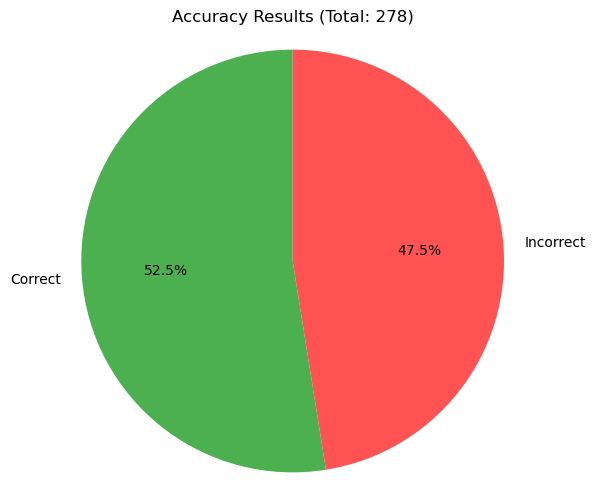

In [ ]:
import matplotlib.pyplot as plt

incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Accuracy Results (Total: {total_examples})')
plt.axis('equal')

plt.show()


# One-shot

In [ ]:
def classify_with_one_shot(ticket_text, components_list,correct):

    components_context = "\n".join([f"- {c['name']}: {c['description']}" for c in components])
    comp_names_list = [c['name'] for c in components]

    examples = """
    ### EXAMPLE
    Ticket: "I have been using the Predictive Analytics Module for quite some time, and I must say that the recent erratic forecasts generated by the machine learning algorithms are highly concerning. The inaccurate risk assessments and suboptimal decision-making processes are causing significant financial losses and operational inefficiencies in the Agriculture industry. It's critical that this issue is addressed promptly to prevent further misleading insights hindering our informed business decisions."
    Correct Component: Predictive Analytics Module
    """


    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Identify which technical component is most likely responsible for the issue.

    CANDIDATE COMPONENTS (Name: Description)
    {components_context}

    RULES:
    - Choose exactly ONE component from the list.
    - Output ONLY the component name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {comp_names_list}

    ### CURRENT TASK
    Ticket: "{ticket_text}"
    Correct Component:
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0}
    )

    pred = response["message"]["content"].strip()

    return (pred,pred==correct)

In [ ]:
with open('generated_dataset.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_one_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })
print(f"Done classification on {total_examples} items...\n")

Starting classification on 40 items...

Done classification on 40 items...



# One shot Evaluation

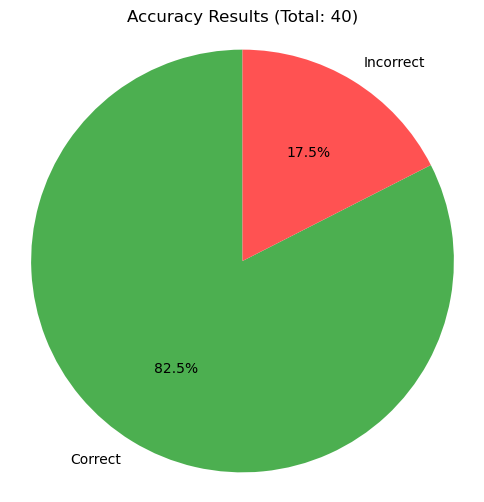

In [ ]:
import matplotlib.pyplot as plt

incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Accuracy Results (Total: {total_examples})')
plt.axis('equal')

plt.show()


# Few-shot

In [ ]:
def classify_with_few_shot(ticket_text, components_list,correct):

    components_context = "\n".join([f"- {c['name']}: {c['description']}" for c in components])
    comp_names_list = [c['name'] for c in components]

    examples = """
    ### EXAMPLE 1
    Ticket: "I have been using the Predictive Analytics Module for quite some time, and I must say that the recent erratic forecasts generated by the machine learning algorithms are highly concerning. The inaccurate risk assessments and suboptimal decision-making processes are causing significant financial losses and operational inefficiencies in the Agriculture industry. It's critical that this issue is addressed promptly to prevent further misleading insights hindering our informed business decisions."
    Correct Component: Predictive Analytics Module

    ### EXAMPLE 2
    Ticket: "I am extremely concerned about the intermittent failures in the data security and governance component. It's imperative that access control is consistently enforced to prevent unauthorized access to sensitive agricultural data. This is a serious security concern that needs urgent attention to avoid potential data breaches and ensure regulatory compliance!"
    Correct Component: Data Security and Governance
    """


    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Identify which technical component is most likely responsible for the issue.

    CANDIDATE COMPONENTS (Name: Description)
    {components_context}

    RULES:
    - Choose exactly ONE component from the list.
    - Output ONLY the component name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {comp_names_list}

    ### CURRENT TASK
    Ticket: "{ticket_text}"
    Correct Component:
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0}
    )

    pred = response["message"]["content"].strip()

    return (pred,pred==correct)

In [ ]:
ticket_text="I have encountered a critical issue with the HRM Workflow Engine. Despite being experienced with the system, I am encountering a major roadblock in the offboarding process. The engine fails to trigger the necessary state transitions for employee offboarding, leaving departing employees with active access to critical systems and applications. This poses a significant security risk to the organization, potentially leading to unauthorized access, data breaches, and compliance violations. I urge for immediate attention to rectify this issue as it severely impacts our ability to maintain a secure offboarding process."

workflow_description ={
     "workflow_name": "Employee Lifecycle Management in Energy Industry",
     "workflow_description": "This workflow manages the complete lifecycle of employees within the energy industry, including processes related to recruitment, onboarding, performance management, and offboarding.",
     "workflow_components": [
         {
             "name": "HRM Workflow Engine",
             "description": "Orchestrates process logic, approval routing, and state transitions for employee lifecycle events (recruitment, onboarding, performance, offboarding)."
         },
         {
             "name": "Employee Data Store",
             "description": "Centralized database housing employee profiles, employment history, skills, and certifications."
         },
         {
             "name": "Payroll Processing Module",
             "description": "Computes salaries, tax deductions, and benefits, integrates with financial systems for budgeting and forecasting."
         },
         {
             "name": "Attendance Tracking System",
             "description": "Manages shift scheduling, clock-in/out logs, leave requests (PTO), and overtime calculations for employees in various operational roles in the energy industry."
         },
         {
             "name": "Learning and Development Platform",
             "description": "Tracks employee training, certifications, and development plans aligned with industry regulations and safety standards."
         }
     ]
 }

correct = "HRM Workflow Engine"
pred, was_right = classify_with_few_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: HRM Workflow Engine, Is Correct: True


In [ ]:
ticket_text="This is a critical security concern! The Feedback and Survey Management system is failing to capture patient feedback and satisfaction surveys, which is essential for improving service quality and patient experience. This issue severely hinders our ability to assess and address customer satisfaction, potentially leading to customer dissatisfaction and negatively impacting service quality. Urgent action is needed to address this issue and protect sensitive patient data."

workflow_description ={
      "workflow_name": "Client Relationship Management in Healthcare",
      "workflow_description": "This workflow involves the management of interactions and communications with current and potential clients within the healthcare industry. It aims to track patient interactions, manage appointments, and support various customer service activities.",
      "workflow_components": [
        {
          "name": "Patient Information Management System",
          "description": "Centralized database for storing patient information, medical history, treatment plans, and appointment schedules."
        },
        {
          "name": "Appointment Scheduling Module",
          "description": "Facilitates the booking of patient appointments, manages availability of healthcare providers, and sends appointment reminders."
        },
        {
          "name": "Communication and Engagement Platform",
          "description": "Enables communication with patients via multiple channels such as email, SMS, and patient portal for sharing educational materials, test results, and follow-up instructions."
        },
        {
          "name": "Feedback and Survey Management",
          "description": "Captures patient feedback, satisfaction surveys, and helps in analyzing patient experience to improve service quality."
        },
        {
          "name": "Analytics and Reporting Tool",
          "description": "Generates insights on patient interactions, appointment trends, and client preferences to support strategic decision-making."
        }
      ]
    }

correct = "Feedback and Survey Management"
pred, was_right = classify_with_few_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: HRM Workflow Engine, Is Correct: False


In [ ]:
workflow_description ={
    "workflow_name": "Electronic Document Management in Healthcare",
    "workflow_description": "This workflow involves the management and tracking of electronic documents and images in the healthcare industry, enabling storage and retrieval of critical patient and administrative records.",
    "workflow_components": [
        {
            "name": "Document Storage Repository",
            "description": "Centralized storage system for storing electronic documents and images, integrated with data archival policies and access control mechanisms to ensure data integrity and security."
        },
        {
            "name": "Metadata Management System",
            "description": "Captures and organizes metadata associated with medical records and administrative documents, facilitating efficient indexing, search, and retrieval processes."
        },
        {
            "name": "Workflow Automation Engine",
            "description": "Orchestrates document approval workflows, version control, and notification mechanisms, ensuring seamless collaboration and compliance with regulatory requirements."
        },
        {
            "name": "Record Tracking and Audit Trail",
            "description": "Maintains an audit trail of document access, modifications, and viewing history, providing transparency and accountability for document handling within the healthcare organization."
        },
        {
            "name": "Integration Interfaces",
            "description": "Provides interfaces for integration with Electronic Health Records (EHR) systems, Imaging systems, and third-party applications, enabling seamless exchange of information across healthcare platforms."
        }
    ]
}


ticket_text="This is an urgent situation! The Integration Interfaces are failing to connect with the Electronic Health Records (EHR) systems and Imaging systems, putting patient data at risk. As an experienced user, I understand the severity of this security concern and the potential impact on patient care."

correct = "Integration Interfaces"
pred, was_right = classify_with_few_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: Payroll Processing Module, Is Correct: False


In [ ]:
ticket_text="I am really frustrated with the System! It's not capturing and storing student feedback and course evaluations properly. This is a critical issue as it directly impacts the institution's ability to assess and improve course performance, and it's compromising the quality of teaching. I'm worried about the security of the feedback data too!"

workflow_description ={
      "workflow_name": "Student Enrollment and Course Management",
      "workflow_description": "This workflow handles the student enrollment process and the management of courses within an educational institution, ensuring efficient allocation of resources and optimal student experience.",
      "workflow_components": [
        {
          "name": "Student Information System",
          "description": "Centralized database storing student records, academic performance, and course selection data."
        },
        {
          "name": "Course Scheduler",
          "description": "Module for creating and managing class schedules, allocating resources, and ensuring course availability for students."
        },
        {
          "name": "Financial Aid Management System",
          "description": "Handles the application, verification, and distribution of financial aid to eligible students."
        },
        {
          "name": "Resource Allocation Engine",
          "description": "Optimizes the allocation of physical and human resources based on course demand and availability."
        },
        {
          "name": "Course Evaluation and Feedback System",
          "description": "Facilitates student feedback, course evaluations, and performance assessments to improve teaching quality."
        }
      ]
    }

correct = "Course Evaluation and Feedback System"
pred, was_right = classify_with_few_shot(ticket_text, workflow_description['workflow_components'],correct)
count+= was_right

print(f"Prediction: {pred}, Is Correct: {was_right}")

Prediction: Learning and Development Platform, Is Correct: False


In [ ]:
with open('generated_dataset.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    ticket = item['user_complaint']['user_complaint']

    components = item['workflow']['workflow_components']

    correct_answer = item['malfunction']['affected_component']['name']

    pred, was_right = classify_with_few_shot(ticket, components, correct_answer)

    count += was_right

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_answer
    })
print(f"Done classification on {total_examples} items...\n")

Starting classification on 278 items...

Done classification on 278 items...



# Few Shot Evaluation

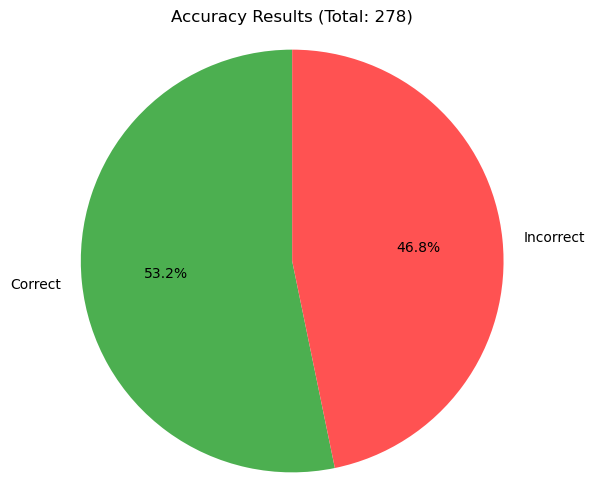

In [ ]:
import matplotlib.pyplot as plt

incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Accuracy Results (Total: {total_examples})')
plt.axis('equal')

plt.show()


# Fine Tuned model - Component classification

In [ ]:
#!pip install jupyter_contrib_nbextensions
#!jupyter contrib nbextension install --user
#!jupyter nbextension enable varInspector/main

In [ ]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension
#!pip install accelerate -U
#!pip install -q transformers datasets evaluate scikit-learn accelerate
#!pip install --upgrade ipywidgets
#!jupyter nbextension enable --py widgetsnbextension --sys-prefix
#!jupyter nbextension install --py widgetsnbextension --sys-prefix

## Dataprocess

In [ ]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset

# choose dataset file
filename = 'generated_dataset.json'

def load_and_process_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    processed_data = []
    for entry in data:
        # Input Sequence
        input_text = f"System: {entry['system']['system']} | Industry: {entry['industry']['industry']} | Complaint: {entry['user_complaint']['user_complaint']}"

        # predictable labels
        label = entry['malfunction']['affected_component']['name']

        processed_data.append({
            'text': input_text,
            'label_name': label
        })

    return pd.DataFrame(processed_data)

df = load_and_process_data(filename)

# number labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['label_name'])

# dict of number ~ label
label2id = {label: i for i, label in enumerate(le.classes_)}
id2label = {i: label for i, label in enumerate(le.classes_)}

# split to 75% train 15% validation 10% test
train_df, temp_df = train_test_split(df, test_size=0.25, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.4, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)


## Tokenization

In [ ]:
from transformers import DistilBertTokenizerFast

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# input id & attention max are being added as columns
print(train_tokenized.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

['text', 'label_name', 'label', '__index_level_0__', 'input_ids', 'attention_mask']


## Train

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
import torch

model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=30,              # how many times its gon go through the dataset
    per_device_train_batch_size=4,   # how many examples per batch
    per_device_eval_batch_size=4,
    learning_rate=2e-5,              # learning rate, not too high so it wont forget the things it already knew
    warmup_steps=50,
    logging_dir='./logs',
    logging_steps=10,
    weight_decay=0.01,               # tax weight -> anti-overfit
    load_best_model_at_end=True,     # save the 'best' model out of the 5 rounds.
    eval_strategy="epoch",       # will test itself while running on data it has yet to see
    save_strategy="epoch",           # checkpoint per round
    report_to="none"
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

save_path = "./my_component_classifier_le"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,4.737300,4.687205,0.044444
2,4.555200,4.592455,0.044444
3,4.428900,4.486662,0.066667
4,4.051500,4.361494,0.066667
5,4.054300,4.254537,0.088889
6,3.766600,4.176252,0.111111
7,3.136100,4.090536,0.088889
8,3.318100,4.031315,0.111111
9,2.918900,3.959932,0.133333
10,2.722700,3.911572,0.177778


Model saved to ./my_component_classifier_le


## Test Set Result

In [ ]:
print("Running final evaluation on the 10% Test Set...")
test_results = trainer.predict(test_tokenized)

print("Test Set Metrics:", test_results.metrics)

final_acc = test_results.metrics['test_accuracy']
print(f"Final Accuracy on Test Set: {final_acc:.2%}")

Running final evaluation on the 10% Test Set...


Test Set Metrics: {'test_loss': 3.4073259830474854, 'test_accuracy': 0.3, 'test_runtime': 0.19, 'test_samples_per_second': 157.865, 'test_steps_per_second': 42.097}
Final Accuracy on Test Set: 30.00%


## Inference

In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

save_path = "./my_component_classifier_le"
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_path)
loaded_tokenizer = DistilBertTokenizerFast.from_pretrained(save_path)

def predict_component(system, industry, complaint):
    text_input = f"System: {system} | Industry: {industry} | Complaint: {complaint}"

    inputs = loaded_tokenizer(text_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        logits = loaded_model(**inputs).logits

    #find index of highest prob
    predicted_class_id = logits.argmax().item()

    # from num to label
    predicted_label = loaded_model.config.id2label[predicted_class_id]

    return predicted_label

## Tests on the model

In [ ]:
# test on 1
new_system = "Supply Chain Management System"
new_industry = "Retail"
new_complaint = "The warehouse scanners are lagging and not updating the inventory counts in real time."

prediction = predict_component(new_system, new_industry, new_complaint)

print("-" * 50)
print(f"System: {new_system}")
print(f"Complaint: {new_complaint}")
print(f"Predicted Faulty Component: {prediction}")
print("-" * 50)

--------------------------------------------------
System: Supply Chain Management System
Complaint: The warehouse scanners are lagging and not updating the inventory counts in real time.
Predicted Faulty Component: Payroll Processing Module
--------------------------------------------------


In [ ]:
import json
import torch
from sklearn.metrics import classification_report, accuracy_score
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

model_path = "./my_component_classifier_le"
test_file_path = "test_data_60.json"

print("Loading model and tokenizer...")

model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

# turning the model to eval mode
model.eval()

print(f"Loading test data from {test_file_path}...")
with open(test_file_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

y_true = []       # ground truth array
y_pred = []       # predictions array

print("Running predictions...")

for i, entry in enumerate(test_data):
    # formatting so it would look the same as trained
    text_input = f"System: {entry['system']['system']} | Industry: {entry['industry']['industry']} | Complaint: {entry['user_complaint']['user_complaint']}"

    # saving ground truth
    true_label = entry['malfunction']['affected_component']['name']

    # tokenazting for model
    inputs = tokenizer(text_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

    # running the model
    with torch.no_grad():
        logits = model(**inputs).logits

    # translating vector to labels
    predicted_id = logits.argmax().item()
    predicted_label = model.config.id2label[predicted_id]

    y_true.append(true_label)
    y_pred.append(predicted_label)

    # printing as it runs to shows it works
    if i % 10 == 0:
        print(f"Example {i}: True='{true_label}' | Pred='{predicted_label}'")


Loading model and tokenizer...
Loading test data from test_data_60.json...
Running predictions...
Example 0: True='Inventory Management System' | Pred='Inventory Management System'
Example 10: True='Appointment Scheduling Module' | Pred='Metadata Management System'
Example 20: True='Card Authorization Module' | Pred='Attendance Tracking System'
Example 30: True='Clinical Decision Support System (CDSS)' | Pred='Digital Rights Management (DRM)'
Example 40: True='DCS (Departure Control System)' | Pred='Workflow Automation Tool'
Example 50: True='Currency Converter' | Pred='Payroll Processing Module'


In [ ]:
# Evaluation Metrics
print("\n" + "="*40)
print("FINAL TEST REPORT")
print("="*40)

accuracy = accuracy_score(y_true, y_pred)
print(f"Total Accuracy: {accuracy:.2%}")

print("-" * 40)
print("Detailed Classification Report:")

#detailed table of results
print(classification_report(y_true, y_pred, zero_division=0))


FINAL TEST REPORT
Total Accuracy: 8.33%
----------------------------------------
Detailed Classification Report:
                                                precision    recall  f1-score   support

AMI (Advanced Metering Infrastructure) Headend       0.00      0.00      0.00         1
                         Access Control Module       0.00      0.00      0.00         1
                 Appointment Scheduling Module       0.00      0.00      0.00         1
                      Approval Workflow Engine       0.00      0.00      0.00         1
                    Attendance Tracking System       0.00      0.00      0.00         1
                     Card Authorization Module       0.00      0.00      0.00         1
                    Central Reservation System       0.00      0.00      0.00         1
                      Chain of Custody Tracker       0.00      0.00      0.00         1
       Clinical Decision Support System (CDSS)       0.00      0.00      0.00         1
     

# Classification for severity

## Data Process

In [ ]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset, DatasetDict

filename = 'generated_dataset.json'

def load_and_process_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    processed_data = []
    for entry in data:
        text_input = f"""
        Industry: {entry['industry']['industry']}
        System: {entry['system']['system']}
        Workflow: {entry['workflow']['workflow_name']}
        Malfunction: {entry['malfunction']['malfunction_description']}
        User Complaint: {entry['user_complaint']['user_complaint']}
        """.strip()

        label = entry['malfunction']['severity']

        processed_data.append({
            'text': text_input,
            'label_name': label
        })

    return pd.DataFrame(processed_data)

df = load_and_process_data(filename)


le = LabelEncoder()
df['label'] = le.fit_transform(df['label_name'])

label2id = {label: i for i, label in enumerate(le.classes_)}
id2label = {i: label for i, label in enumerate(le.classes_)}

print(f"Classes Mapping: {id2label}")

# split to 75% train 15% validation 10% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df['label']
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.40,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

## Tokenization

In [ ]:
from transformers import AutoTokenizer

hf_data = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_data.map(tokenize_function, batched=True)

print("Tokenization complete.")

## Train

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, average='weighted')

    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir="./severity_results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)


print("Starting training for Severity Classification...")
trainer.train()

save_path = "./my_severity_classifier"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

## Test Set Result

In [ ]:
print("Running final evaluation on the 10% Test Set...")

test_results = trainer.predict(tokenized_datasets["test"])

print("Test Set Metrics:", test_results.metrics)

final_acc = test_results.metrics['test_accuracy']
print(f"Final Accuracy on Test Set: {final_acc:.2%}")

## Inference

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "./my_component_classifier_le"
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

def predict_component(system, industry, complaint):

    text_input = f"System: {system} | Industry: {industry} | Complaint: {complaint}"

    inputs = tokenizer(text_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        logits = model(**inputs).logits

    pred_id = logits.argmax().item()
    return model.config.id2label[pred_id]

## Tests on the model

In [ ]:
# test on 1
new_system = "Supply Chain Management System"
new_industry = "Retail"
new_complaint = "The warehouse scanners are lagging and not updating the inventory counts in real time."

prediction = predict_component(new_system, new_industry, new_complaint)

print("-" * 50)
print(f"System: {new_system}")
print(f"Complaint: {new_complaint}")
print(f"Predicted Faulty Component: {prediction}")
print("-" * 50)

In [ ]:
# test on data set of 60
import json
import torch
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer


model_path = "./my_severity_classifier"
test_file_path = "test_data_60.json"

print(f"Loading model from {model_path}...")

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

model.eval()

print(f"Loading test data from {test_file_path}...")
with open(test_file_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

y_true = []
y_pred = []

print("Running severity predictions...")

for i, entry in enumerate(test_data):
    text_input = f"""
    Industry: {entry['industry']['industry']}
    System: {entry['system']['system']}
    Workflow: {entry['workflow']['workflow_name']}
    Malfunction: {entry['malfunction']['malfunction_description']}
    User Complaint: {entry['user_complaint']['user_complaint']}
    """.strip()

    true_label = entry['malfunction']['severity']

    inputs = tokenizer(text_input, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        logits = model(**inputs).logits

    predicted_id = logits.argmax().item()
    predicted_label = model.config.id2label[predicted_id]

    y_true.append(true_label)
    y_pred.append(predicted_label)

print("\n" + "="*40)
print("SEVERITY MODEL - TEST RESULTS")
print("="*40)

acc = accuracy_score(y_true, y_pred)
print(f"Total Accuracy: {acc:.2%}")

print("-" * 40)
print("Detailed Classification Report:")

print(classification_report(y_true, y_pred, zero_division=0))

## something chat said that works well for jupyter

In [ ]:
import pandas as pd
import numpy as np

# שליפת התחזיות (המספרים) מהתוצאות
predictions = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids

# יצירת טבלה להשוואה
results_df = pd.DataFrame({
    'Text': tokenized_datasets['test']['text'], # הטקסט המקורי
    'True Label': [id2label[i] for i in true_labels], # התווית האמיתית (במילים)
    'Predicted': [id2label[i] for i in predictions]   # מה המודל חשב (במילים)
})

# הוספת עמודה שמראה אם הוא צדק או טעה
results_df['Correct'] = results_df['True Label'] == results_df['Predicted']

# הצגה יפה של הטעויות בלבד (Jupyter יציג את זה כטבלה מעוצבת)
print("Here are the examples where the model failed:")
display(results_df[results_df['Correct'] == False])